# Evaluación — Módulo de Interpolación y Aproximación

**Programación Científica 2026-1 · Universidad Nacional de Colombia**

mbastidaso@unal.edu.co


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/)

---

**Integrantes:** (orden alfabético)
- Apellido1, Nombre1: `Corredor, Julián`
- Apellido2, Nombre2: `Giraldo, Jhoan`

---

## Instrucciones generales

**Duración:** 1.5 horas

**Recursos permitidos:** internet, LLMs, notebooks del curso. No pueden compartir código ni respuestas con otras parejas.

**Entrega — flujo GitHub obligatorio:**

0. Crear una copia de este archivo que se llama `apellido1_apellido2_evaluacion1.ipynb` en la carpeta EVALUACION y sobre ese archivo se harán todos los resultados/cambios/commits.

1. Crear una rama con el nombre exacto: `apellido1_apellido2_5Junio` (orden alfabético, minúsculas, sin tildes, sin espacios).

2. Trabajen **únicamente sobre esa rama**. Deben hacer **exactamente 3 commits** antes de abrir el PR.

3. Los mensajes de commit deben seguir esta convención y cubrir avance real:
   ```
   init: cedulas, seed y generacion de datos
   add: interpolacion spline y ajuste LS
   add: PCA y analisis escritos
   ```

4. Abran un **Pull Request** de su rama a `main`. En el título del PR escriban: `Evaluación [Apellido1] [Apellido2]`.

⚠️ **Penalizaciones automáticas:**
- Notebook que no ejecuta de principio a fin (`Kernel → Restart & Run All`): −10 pts.
- Menos o más de 3 commits: −5 pts.
- Rama con nombre incorrecto: −5 pts.

---

**Distribución de puntos:**

| Sección | Puntos |
|---|---|
| P0 — Inicialización y datos | 5 |
| P1 — Cuestionario conceptual | 20 |
| P2 — Interpolación B-spline 2D | 30 |
| P3 — Ajuste por mínimos cuadrados | 20 |
| P4 — PCA | 15 |
| GitHub (commits + PR + respuesta) | 10 |
| **Total** | **100** |

---
## P0 — Inicialización (5 pts)

Escriban sus números de cédula en las variables indicadas. **No modifiquen ninguna otra línea de esta sección.** Todos los datos del ejercicio se generan a partir de su semilla.

In [1]:
# TODO P0: reemplacen los ceros con sus ID reales
cedula1 = 1118530698
cedula2 = 1007238521

In [2]:
# 🔒 CELDA DE DATOS — no modificar
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RectBivariateSpline
from scipy.linalg import svd

assert cedula1 != 0 and cedula2 != 0, "Deben ingresar sus ID en la celda anterior."

seed = int((cedula1 + cedula2) % 1000)
rng  = np.random.default_rng(seed)

# Parámetros de la superficie — dependen de la semilla
alpha = 1.0 + (seed % 7)  * 0.3          # frecuencia en x: entre 1.0 y 2.8
beta  = 1.0 + (seed % 5)  * 0.4          # frecuencia en y: entre 1.0 y 2.6
gamma = 0.10 + (seed % 11) * 0.02        # decaimiento gaussiano: entre 0.10 y 0.30
noise_std = 0.05 + (seed % 13) * 0.01    # ruido: entre 0.05 y 0.17

# Malla gruesa de muestreo (15x15 puntos)
n  = 15
x_raw = np.linspace(-3, 3, n)
y_raw = np.linspace(-3, 3, n)
X_raw, Y_raw = np.meshgrid(x_raw, y_raw, indexing='ij')

# Elevación verdadera + ruido
Z_true = np.sin(alpha * X_raw) * np.cos(beta * Y_raw) * np.exp(-gamma * (X_raw**2 + Y_raw**2))
Z_data = Z_true + rng.normal(0, noise_std, X_raw.shape)

print(f"Semilla: {seed}")
print(f"Parámetros — alpha: {alpha:.2f}, beta: {beta:.2f}, gamma: {gamma:.3f}, ruido: {noise_std:.3f}")
print(f"Malla de datos: {n}x{n} puntos en [-3,3]x[-3,3]")
print(f"Z_data shape: {Z_data.shape}")

Semilla: 219
Parámetros — alpha: 1.60, beta: 2.60, gamma: 0.300, ruido: 0.160
Malla de datos: 15x15 puntos en [-3,3]x[-3,3]
Z_data shape: (15, 15)


---
## P1 — Cuestionario conceptual (20 pts)

Respondan las siguientes preguntas **sin ejecutar código adicional**. Basen sus respuestas en la lectura del bloque de generación de datos de P0.

### P1.1 (7 pts)

La celda de datos genera `Z_data = Z_true + ruido`. Cuando construyan el spline en P2, este va a **interpolar** `Z_data`, no `Z_true`.

**a)** ¿Qué significa que el spline interpole `Z_data` en lugar de ajustar `Z_true`? ¿El spline va a pasar exactamente por los valores de `Z_data`?  
**b)** ¿En qué condición sería preferible usar mínimos cuadrados en lugar del spline para reconstruir la superficie?

**Respuesta P1.1:**



a) Interpolar `Z_data` significa construir una superficie que pase por los datos medidos en la malla. En este caso, el spline reproduce los valores de `Z_data`, no los de `Z_true`. Como `Z_data` tiene ruido, el spline también termina copiando ese ruido. Por eso, aunque pase exactamente por los puntos, no significa que recupere perfectamente la superficie real.

b) Mínimos cuadrados es preferible cuando los datos tienen ruido y se quiere encontrar una tendencia general. A diferencia del spline, no busca pasar por todos los puntos, sino aproximarse lo mejor posible en conjunto. Esto ayuda a obtener un modelo más suave y menos afectado por pequeñas variaciones aleatorias.


### P1.2 (7 pts)

En P3 van a ajustar un plano $z = c_0 + c_1 x + c_2 y$ a los datos usando mínimos cuadrados.

**a)** ¿Cómo se construye la matriz $A$ del sistema $A\mathbf{c} = \mathbf{z}$ para este modelo? Descríbanla en términos de sus columnas.  
**b)** La función verdadera `Z_true` no es un plano. ¿Qué representa entonces el plano ajustado? ¿Qué información útil les da sobre la superficie?

**Respuesta P1.2:**


a) Para el modelo (z = c_0 + c_1x + c_2y), cada punto ((x_i,y_i,z_i)) genera una ecuación. Por eso, la matriz (A) tiene una fila por cada punto y tres columnas: una columna de unos para (c_0), una columna con los valores de (x_i) para (c_1), y una columna con los valores de (y_i) para (c_2). Como hay 225 datos y solo 3 incógnitas, el sistema se resuelve por mínimos cuadrados.

b) El plano ajustado representa una aproximación lineal global de la superficie. No muestra todas las oscilaciones, sino la tendencia promedio. El coeficiente (c_0) indica el nivel medio, mientras que (c_1) y (c_2) indican la inclinación promedio en las direcciones (x) y (y). Si el plano queda casi horizontal, significa que la superficie no tiene una pendiente global fuerte, sino variaciones locales.


### P1.3 (6 pts)

En P4 van a aplicar PCA a la nube de puntos $(x_i, y_i, z_i)$ formada por los 225 puntos de la malla.

**a)** ¿Por qué es necesario centrar los datos antes de calcular los componentes principales?  
**b)** ¿Qué interpretación geométrica tiene el primer componente principal en el contexto de esta superficie?

**Respuesta P1.3:**

a) Se centran los datos antes de hacer PCA porque este método estudia la variación respecto al promedio. Si no se resta la media, los componentes principales pueden quedar influenciados por la posición de la nube de puntos y no por su verdadera dispersión. Centrar permite analizar mejor la forma y orientación de los datos.

b) El primer componente principal es la dirección donde los puntos tienen mayor variación. Geométricamente, es como el eje principal de la nube de puntos. En este caso, como (x) y (y) se extienden mucho más que (z), es razonable que las primeras componentes estén más relacionadas con el plano horizontal (xy), mientras que la variación vertical queda como una componente menor.


---
**Recordatorio del flujo:**

```bash
# 1. Crear y moverse a su rama
git checkout -b apellido1_apellido2_5Junio

# 2. Primer commit — después de P0 y P1
git add evaluacion_final_modulo.ipynb
git commit -m "init: cedulas, seed y generacion de datos"
```

---
## P2 — Interpolación B-spline 2D (27 pts)

Usen `RectBivariateSpline` de `scipy.interpolate` para construir un spline bicúbico sobre los datos `(x_raw, y_raw, Z_data)`.

### P2.1 — Construcción y evaluación (15 pts)

Construyan el spline con `kx=3, ky=3` y evalúenlo en una malla fina de **100×100 puntos** en $[-3,3]\times[-3,3]$.

In [5]:
# TODO P2.1: construir el spline bicúbico y evaluar en malla fina

# Construimos el spline bicúbico usando los datos ruidosos Z_data
spline = RectBivariateSpline(x_raw, y_raw, Z_data, kx=3, ky=3)

# Malla fina de 100x100 puntos en el dominio [-3,3] x [-3,3]
x_fine = np.linspace(-3, 3, 100)
y_fine = np.linspace(-3, 3, 100)

X_fine, Y_fine = np.meshgrid(x_fine, y_fine, indexing="ij")

# Evaluamos el spline en la malla fina
Z_spline = spline(x_fine, y_fine)

print(f"Malla fina X_fine: {X_fine.shape}")
print(f"Malla fina Y_fine: {Y_fine.shape}")
print(f"Superficie interpolada Z_spline: {Z_spline.shape}")
print(f"Valor mínimo de Z_spline: {Z_spline.min():.4f}")
print(f"Valor máximo de Z_spline: {Z_spline.max():.4f}")


Malla fina X_fine: (100, 100)
Malla fina Y_fine: (100, 100)
Superficie interpolada Z_spline: (100, 100)
Valor mínimo de Z_spline: -0.8031
Valor máximo de Z_spline: 0.8554


### P2.2 — Figura comparativa (15 pts)

Produzcan una figura con **dos paneles side-by-side** (`subplot` 1×2):
- Panel izquierdo: `Z_data` en la malla gruesa (superficie en 3D).
- Panel derecho: superficie interpolada por el spline en la malla fina (3D).

Ambos paneles deben tener: colorbar, ejes etiquetados, y usar el **mismo colormap y los mismos límites de color** (`vmin`/`vmax` iguales en ambos).

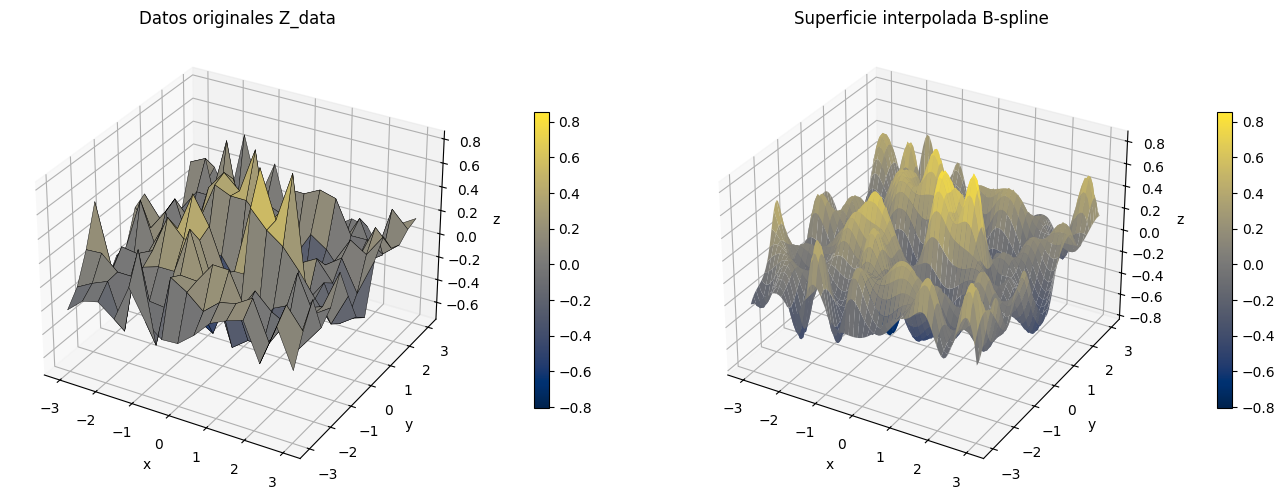

In [7]:
#  P2.2: figura comparativa datos vs spline

from mpl_toolkits.mplot3d import Axes3D

# Mismo colormap y mismos límites de color para ambos paneles
cmap = "cividis"
vmin = min(Z_data.min(), Z_spline.min())
vmax = max(Z_data.max(), Z_spline.max())

fig = plt.figure(figsize=(14, 5))

# Panel izquierdo: datos originales en malla gruesa
ax1 = fig.add_subplot(1, 2, 1, projection="3d")

surf1 = ax1.plot_surface(
    X_raw,
    Y_raw,
    Z_data,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    edgecolor="k",
    linewidth=0.3,
    antialiased=True
)

ax1.set_title("Datos originales Z_data")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("z")

fig.colorbar(surf1, ax=ax1, shrink=0.65, pad=0.1)

# Panel derecho: superficie interpolada en malla fina
ax2 = fig.add_subplot(1, 2, 2, projection="3d")

surf2 = ax2.plot_surface(
    X_fine,
    Y_fine,
    Z_spline,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    edgecolor="none",
    antialiased=True
)

ax2.set_title("Superficie interpolada B-spline")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("z")

fig.colorbar(surf2, ax=ax2, shrink=0.65, pad=0.1)

plt.tight_layout()
plt.show()

---
## P3 — Ajuste por mínimos cuadrados (20 pts)

Ajusten un **plano** $z = c_0 + c_1 x + c_2 y$ a los 225 puntos de la malla usando mínimos cuadrados. Trabajen con los datos ruidosos `Z_data`.

### P3.1 — Ajuste (10 pts)

Construyan la matriz $A$, resuelvan el sistema normal con `np.linalg.lstsq`, e impriman los coeficientes $c_0, c_1, c_2$ con 4 decimales.

In [8]:
# TODO P3.1: construir la matriz A y resolver por mínimos cuadrados

# Convertimos las matrices de la malla en vectores
x_vec = X_raw.ravel()
y_vec = Y_raw.ravel()
z_vec = Z_data.ravel()

# Matriz de diseño para el modelo:
# z = c0 + c1*x + c2*y
# Cada fila tiene la forma [1, x_i, y_i]
A = np.column_stack((
    np.ones_like(x_vec),
    x_vec,
    y_vec
))

# Resolvemos el sistema sobredeterminado usando mínimos cuadrados
coeficientes, residuos_lstsq, rango, valores_singulares = np.linalg.lstsq(
    A,
    z_vec,
    rcond=None
)

# Extraemos los coeficientes del plano
c0, c1, c2 = coeficientes

# Mostramos resultados
print("Coeficientes del plano ajustado:")
print(f"c0 = {c0:.6f}")
print(f"c1 = {c1:.6f}")
print(f"c2 = {c2:.6f}")

print("\nInformación del ajuste:")
print(f"Forma de A: {A.shape}")
print(f"Rango de A: {rango}")
print(f"Valores singulares: {valores_singulares}")

Coeficientes del plano ajustado:
c0 = 0.021283
c1 = -0.000536
c2 = 0.001719

Información del ajuste:
Forma de A: (225, 3)
Rango de A: 3
Valores singulares: [27.77460299 27.77460299 15.        ]


### P3.2 — Residuos y figura (10 pts)

Calculen el mapa de residuos: $R = Z_{\text{data}} - Z_{\text{plano}}$, donde $Z_{\text{plano}}$ es el plano evaluado en la malla gruesa.

Produzcan una figura con **dos paneles**:
- Panel izquierdo: plano ajustado sobre la malla gruesa, con colorbar y ejes etiquetados.
- Panel derecho: mapa de residuos $R$, con colorbar, ejes etiquetados, y colormap **divergente** centrado en cero.

Métricas de residuos:
SSE = 13.784994
RMSE = 0.247521
Residuo mínimo = -0.739242
Residuo máximo = 0.812098
Residuo medio = 4.194176e-18


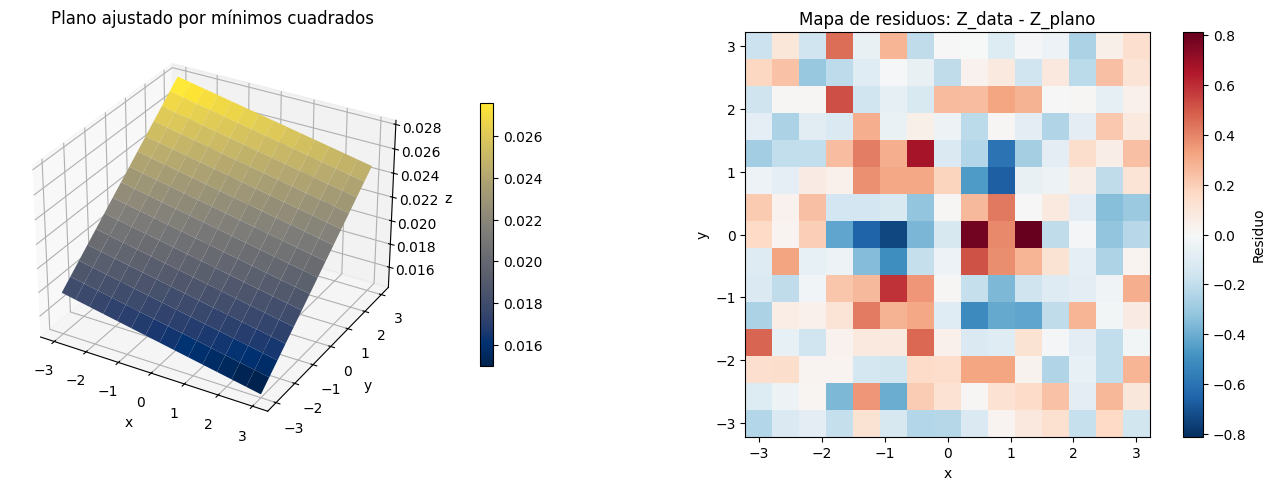

In [9]:
# TODO P3.2: graficar el plano ajustado y el mapa de residuos

from matplotlib.colors import TwoSlopeNorm

# Evaluamos el plano ajustado en la misma malla original
Z_plano = c0 + c1 * X_raw + c2 * Y_raw

# Calculamos los residuos
residuos = Z_data - Z_plano

# Métricas básicas del error
SSE = np.sum(residuos**2)
RMSE = np.sqrt(np.mean(residuos**2))

print("Métricas de residuos:")
print(f"SSE = {SSE:.6f}")
print(f"RMSE = {RMSE:.6f}")
print(f"Residuo mínimo = {residuos.min():.6f}")
print(f"Residuo máximo = {residuos.max():.6f}")
print(f"Residuo medio = {residuos.mean():.6e}")

# Figura comparativa
fig = plt.figure(figsize=(14, 5))

# -------------------------------
# Panel izquierdo: plano ajustado
# -------------------------------
ax1 = fig.add_subplot(1, 2, 1, projection="3d")

surf = ax1.plot_surface(
    X_raw,
    Y_raw,
    Z_plano,
    cmap="cividis",
    edgecolor="none",
    linewidth=0,
    antialiased=True
)

ax1.set_title("Plano ajustado por mínimos cuadrados")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("z")

fig.colorbar(surf, ax=ax1, shrink=0.65, pad=0.1)

# -------------------------------
# Panel derecho: mapa de residuos
# -------------------------------
ax2 = fig.add_subplot(1, 2, 2)

# Centramos la escala de color en cero
rmax = max(abs(residuos.min()), abs(residuos.max()))

norm = TwoSlopeNorm(
    vmin=-rmax,
    vcenter=0,
    vmax=rmax
)

im = ax2.pcolormesh(
    X_raw,
    Y_raw,
    residuos,
    shading="auto",
    cmap="RdBu_r",
    norm=norm
)

ax2.set_title("Mapa de residuos: Z_data - Z_plano")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_aspect("equal", adjustable="box")

fig.colorbar(im, ax=ax2, label="Residuo")

plt.tight_layout()
plt.show()

---
**Recordatorio del flujo:**

```bash
# 1. Crear y moverse a su rama
git checkout -b apellido1_apellido2_5Junio

# 2. Primer commit — después de P0 y P1
git add evaluacion_final_modulo.ipynb
git commit -m "init: cedulas, seed y generacion de datos"

# 3. Segundo commit — después de P2 y P3
git add evaluacion_final_modulo.ipynb
git commit -m "add: interpolacion spline y ajuste LS"
```

---
## P4 — PCA sobre señales sísmicas (15 pts)

Una red de 20 sensores sísmicos registra vibraciones del terreno durante 50 instantes
de tiempo. Las señales están contaminadas con ruido.

In [ ]:
omega1 = 1.0 + (seed % 7) * 0.3
omega2 = 1.0 + (seed % 5) * 0.4

m, p = 20, 50
t = np.linspace(0, 2*np.pi, p)

rng2 = np.random.default_rng(seed + 1)
a = rng2.uniform(0.5, 2.0, m)
b = rng2.uniform(0.5, 2.0, m)

X = np.outer(a, np.cos(omega1 * t)) + np.outer(b, np.sin(omega2 * t))
X += rng.normal(0, 0.3, X.shape)

print(f"Señales: {m} sensores x {p} instantes")
print(f"omega1={omega1:.2f}, omega2={omega2:.2f}")

### P4.1 — Cálculo de componentes principales (7 pts)

Centren las filas de `X` y calculen la SVD con `np.linalg.svd`.

Produzcan una figura con **dos paneles**:
- Panel izquierdo: varianza explicada por cada componente (gráfico de barras).
- Panel derecho: varianza acumulada vs k (puntos + línea), con una línea
  horizontal punteada en el 85%.

Ambos paneles con ejes etiquetados y título.

### P4.2 — Proyección en el espacio PCA (8 pts)

Calculen los scores proyectando las 20 señales centradas sobre los primeros k
componentes que explique más del 89% de la varianza (2 o 3).

Produzcan un scatter de los 20 sensores en el espacio de los primeros k PCs:
- Si k=2: scatter PC1 vs PC2, coloreado por índice de sensor, con colorbar
  y etiquetas de sensor en cada punto.
- Si k=3: tres paneles PC1 vs PC2, PC1 vs PC3, PC2 vs PC3.

En todos los casos: ejes etiquetados con el nombre del componente (`"PC1"`, `"PC2"`...),
líneas en cero, grid, título con el porcentaje de varianza acumulada capturada.

---
## GitHub (10 pts)

Esta sección se califica directamente desde el PR. No hay celdas adicionales.

**Recordatorio del flujo:**

```bash
# 1. Crear y moverse a su rama
git checkout -b apellido1_apellido2_5Junio

# 2. Primer commit — después de P0 y P1
git add evaluacion_final_modulo.ipynb
git commit -m "init: cedulas, seed y generacion de datos"

# 3. Segundo commit — después de P2 y P3
git add evaluacion_final_modulo.ipynb
git commit -m "add: interpolacion spline y ajuste LS"

# 4. Tercer commit — después de P4 y todos los análisis escritos
git add evaluacion_final_modulo.ipynb
git commit -m "add: PCA y analisis escritos"

# 5. Push y abrir PR
git push origin apellido1_apellido2_5Junio
```

Luego en GitHub: **New Pull Request** → base: `main` ← compare: `apellido1_apellido2_5Junio`.

Título del PR: `Evaluación [Apellido1] [Apellido2]`
